## Figure 2F - Plasma Cell Pathways
### Source:
1. https://www.nature.com/articles/s41467-022-33944-z
2. https://pubmed.ncbi.nlm.nih.gov/20574050/

In [1]:
suppressPackageStartupMessages({
  library(dplyr)
  library(ggplot2)
  library(tidyr)
})

normalize_pathway <- function(x) {
  toupper(trimws(x))
}

make_pathway_display <- function(pathway, max_label_length = 40) {
  label <- ifelse(
    nchar(pathway) > max_label_length,
    paste0(substr(pathway, 1, max_label_length), "..."),
    pathway
  )
  toupper(label)
}

select_pathways <- function(data,
                            method = c("top_n", "pattern", "manual", "per_cell_top"),
                            n = 20,
                            pattern = NULL,
                            pathway_list = NULL,
                            padj_threshold = 0.05,
                            require_significant = FALSE) {
  method <- match.arg(method)

  required_cols <- c("pathway", "NES")
  missing_cols <- setdiff(required_cols, names(data))
  if (length(missing_cols) > 0) {
    stop("data must contain columns: ", paste(missing_cols, collapse = ", "))
  }

  if (!"padj" %in% names(data) && method %in% c("top_n", "per_cell_top")) {
    stop("method = '", method, "' requires a 'padj' column in data")
  }

  if (method == "per_cell_top" && !"celltype" %in% names(data)) {
    stop("method = 'per_cell_top' requires a 'celltype' column in data")
  }

  if (method == "top_n") {
    dat <- data %>% filter(!is.na(padj), padj < padj_threshold)

    if (nrow(dat) == 0) {
      warning("No significant pathways found with padj < ", padj_threshold)
      return(character(0))
    }

    return(
      dat %>%
        group_by(pathway) %>%
        summarise(
          mean_abs_nes = mean(abs(NES), na.rm = TRUE),
          min_padj = min(padj, na.rm = TRUE),
          n_sig_cells = n(),
          .groups = "drop"
        ) %>%
        arrange(desc(n_sig_cells), min_padj, desc(mean_abs_nes)) %>%
        slice_head(n = n) %>%
        pull(pathway) %>%
        as.character()
    )
  }

  if (method == "pattern") {
    if (is.null(pattern)) {
      stop("pattern must be provided when method = 'pattern'")
    }

    matched_pathways <- unique(data$pathway)[
      grepl(pattern, unique(data$pathway), ignore.case = TRUE)
    ]

    if (length(matched_pathways) == 0) {
      warning("No pathways matched the pattern: ", pattern)
    }

    return(as.character(matched_pathways))
  }

  if (method == "manual") {
    if (is.null(pathway_list)) {
      stop("pathway_list must be provided when method = 'manual'")
    }

    data_pathways <- unique(data$pathway)
    data_norm <- normalize_pathway(data_pathways)
    list_norm <- normalize_pathway(pathway_list)

    matched <- character(0)
    for (pathway in list_norm) {
      idx <- which(data_norm == pathway)
      if (length(idx) > 0) {
        matched <- c(matched, data_pathways[idx[1]])
      }
    }

    if (length(matched) == 0) {
      warning("No pathways matched from the manual list")
    }

    return(as.character(matched))
  }

  dat_sel <- data
  if (require_significant) {
    dat_sel <- dat_sel %>% filter(!is.na(padj), padj < padj_threshold)
  }

  if (nrow(dat_sel) == 0) {
    warning("No pathways available after filtering")
    return(character(0))
  }

  dat_sel %>%
    group_by(celltype, pathway) %>%
    summarise(
      mean_abs_nes = mean(abs(NES), na.rm = TRUE),
      min_padj = min(padj, na.rm = TRUE),
      .groups = "drop"
    ) %>%
    group_by(celltype) %>%
    arrange(min_padj, desc(mean_abs_nes), .by_group = TRUE) %>%
    slice_head(n = n) %>%
    ungroup() %>%
    pull(pathway) %>%
    unique() %>%
    as.character()
}

create_pathway_heatmap <- function(data,
                                   celltypes = NULL,
                                   pathway_method = "top_n",
                                   n_pathways = 20,
                                   pathway_pattern = NULL,
                                   pathway_list = NULL,
                                   pathway_categories = NULL,
                                   padj_threshold = 0.05,
                                   require_significant = FALSE,
                                   title = NULL,
                                   plot_width = 16,
                                   plot_height = 8,
                                   max_label_length = 40,
                                   base_font_size = 16,
                                   axis_text_x_size = 10,
                                   axis_text_y_size = 10,
                                   strip_text_size = 14,
                                   legend_title_size = 10,
                                   legend_text_size = 9,
                                   axis_text_x_angle = 45,
                                   facet_ncol = NULL) {
  required_cols <- c("celltype", "pathway", "NES", "padj")
  missing_cols <- setdiff(required_cols, names(data))
  if (length(missing_cols) > 0) {
    stop("Data missing required columns: ", paste(missing_cols, collapse = ", "))
  }

  if (is.null(celltypes)) {
    celltypes <- sort(unique(data$celltype))
    message("Using all ", length(celltypes), " cell types found in data")
  } else {
    celltypes_with_data <- unique(data$celltype)
    celltypes <- sort(celltypes[celltypes %in% celltypes_with_data])
    message("Filtered to ", length(celltypes), " cell types that have data")
  }

  if (length(celltypes) == 0) {
    stop("No requested cell types were found in data")
  }

  data <- data %>% filter(celltype %in% celltypes)

  selected_pathways <- select_pathways(
    data,
    method = pathway_method,
    n = n_pathways,
    pattern = pathway_pattern,
    pathway_list = pathway_list,
    padj_threshold = padj_threshold,
    require_significant = require_significant
  )

  if (length(selected_pathways) == 0) {
    stop("No pathways selected with current criteria")
  }

  message("Selected ", length(selected_pathways), " pathways")

  pathway_to_category <- NULL
  category_order <- NULL

  if (!is.null(pathway_categories)) {
    if (!is.list(pathway_categories) || is.null(names(pathway_categories))) {
      stop("pathway_categories must be a named list")
    }

    category_order <- names(pathway_categories)
    pathway_to_category <- character()

    for (category_name in category_order) {
      category_pathways <- pathway_categories[[category_name]]
      category_norm <- normalize_pathway(category_pathways)

      for (pathway in selected_pathways) {
        if (normalize_pathway(pathway) %in% category_norm) {
          pathway_to_category[pathway] <- category_name
        }
      }
    }

    uncategorized <- selected_pathways[!selected_pathways %in% names(pathway_to_category)]
    if (length(uncategorized) > 0) {
      warning(
        "Some pathways do not have categories assigned: ",
        paste(head(uncategorized, 3), collapse = ", "),
        if (length(uncategorized) > 3) {
          paste0(" (and ", length(uncategorized) - 3, " more)")
        } else {
          ""
        }
      )

      pathway_to_category[uncategorized] <- "Other"
      category_order <- unique(c(category_order, "Other"))
    }

    ordered_pathways <- character(0)
    for (category_name in category_order) {
      category_pathways <- names(pathway_to_category)[pathway_to_category == category_name]

      if (category_name == "Other") {
        ordered_pathways <- c(ordered_pathways, category_pathways)
        next
      }

      original_order <- pathway_categories[[category_name]]
      original_norm <- normalize_pathway(original_order)
      category_norm <- normalize_pathway(category_pathways)

      for (original_pathway in original_norm) {
        idx <- which(category_norm == original_pathway)
        if (length(idx) > 0) {
          ordered_pathways <- c(ordered_pathways, category_pathways[idx[1]])
        }
      }
    }

    selected_pathways <- ordered_pathways
  }

  pathway_display_levels <- make_pathway_display(selected_pathways, max_label_length)

  complete_grid <- expand.grid(
    celltype = celltypes,
    pathway = selected_pathways,
    stringsAsFactors = FALSE
  )

  plot_data <- complete_grid %>%
    left_join(
      data %>% filter(pathway %in% selected_pathways),
      by = c("celltype", "pathway")
    ) %>%
    mutate(
      is_na_data = is.na(NES),
      NES = ifelse(is.na(NES), 0, NES),
      padj = ifelse(is.na(padj), 1, padj),
      sig = padj < padj_threshold,
      celltype = factor(celltype, levels = celltypes),
      pathway_display = make_pathway_display(pathway, max_label_length),
      pathway_display = factor(pathway_display, levels = pathway_display_levels)
    )

  if (!is.null(pathway_categories)) {
    plot_data <- plot_data %>%
      mutate(
        pathway_category = factor(pathway_to_category[pathway], levels = category_order)
      )
  }

  max_abs_nes <- max(abs(plot_data$NES), na.rm = TRUE)
  if (!is.finite(max_abs_nes) || max_abs_nes == 0) {
    max_abs_nes <- 1
  }

  main_plot <- ggplot(plot_data, aes(x = pathway_display, y = celltype, fill = NES)) +
    geom_tile(color = "black", linewidth = 0.2) +
    scale_fill_gradient2(
      low = "darkgreen",
      mid = "white",
      high = "deeppink3",
      midpoint = 0,
      na.value = "grey90",
      name = "NES",
      limits = c(-max_abs_nes, max_abs_nes),
      guide = guide_colorbar(
        title.position = "top",
        title.hjust = 0.5,
        barwidth = 1,
        barheight = 6
      )
    ) +
    scale_y_discrete(limits = celltypes, drop = FALSE) +
    labs(x = NULL, y = NULL) +
    theme_minimal(base_size = base_font_size) +
    theme(
      axis.text.x = element_text(
        angle = axis_text_x_angle,
        hjust = 1,
        size = axis_text_x_size,
        color = "black"
      ),
      axis.text.y = element_text(size = axis_text_y_size, color = "black"),
      legend.position = "right",
      legend.title = element_text(size = legend_title_size, face = "bold"),
      legend.text = element_text(size = legend_text_size),
      legend.box = "vertical",
      legend.box.spacing = unit(0.3, "cm"),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      strip.background = element_rect(fill = "white", color = "white"),
      strip.text = element_text(size = strip_text_size, face = "bold", color = "black"),
      panel.spacing = unit(0.2, "cm"),
      plot.title = element_blank()
    )

  if (!is.null(pathway_categories)) {
    main_plot <- main_plot +
      facet_grid(. ~ pathway_category, scales = "free_x", space = "free_x") +
      theme(
        strip.placement = "outside",
        strip.text.x = element_text(size = strip_text_size, face = "bold"),
        axis.text.y.left = element_text(size = axis_text_y_size),
        axis.text.y.right = element_blank()
      )
  }

  sig_data <- plot_data %>% filter(sig)
  if (nrow(sig_data) > 0) {
    main_plot <- main_plot +
      geom_point(
        data = sig_data,
        aes(x = pathway_display, y = celltype),
        shape = 21,
        fill = "white",
        color = "white",
        size = 2,
        stroke = 0.3,
        inherit.aes = FALSE
      )
  }

  if (!is.null(title)) {
    main_plot <- main_plot +
      ggtitle(title) +
      theme(plot.title = element_text(size = 16, face = "bold", hjust = 0.5))
  }

  options(repr.plot.width = plot_width, repr.plot.height = plot_height, repr.plot.res = 200)

  main_plot
}


Using all 11 cell types found in data



Selected 14 pathways



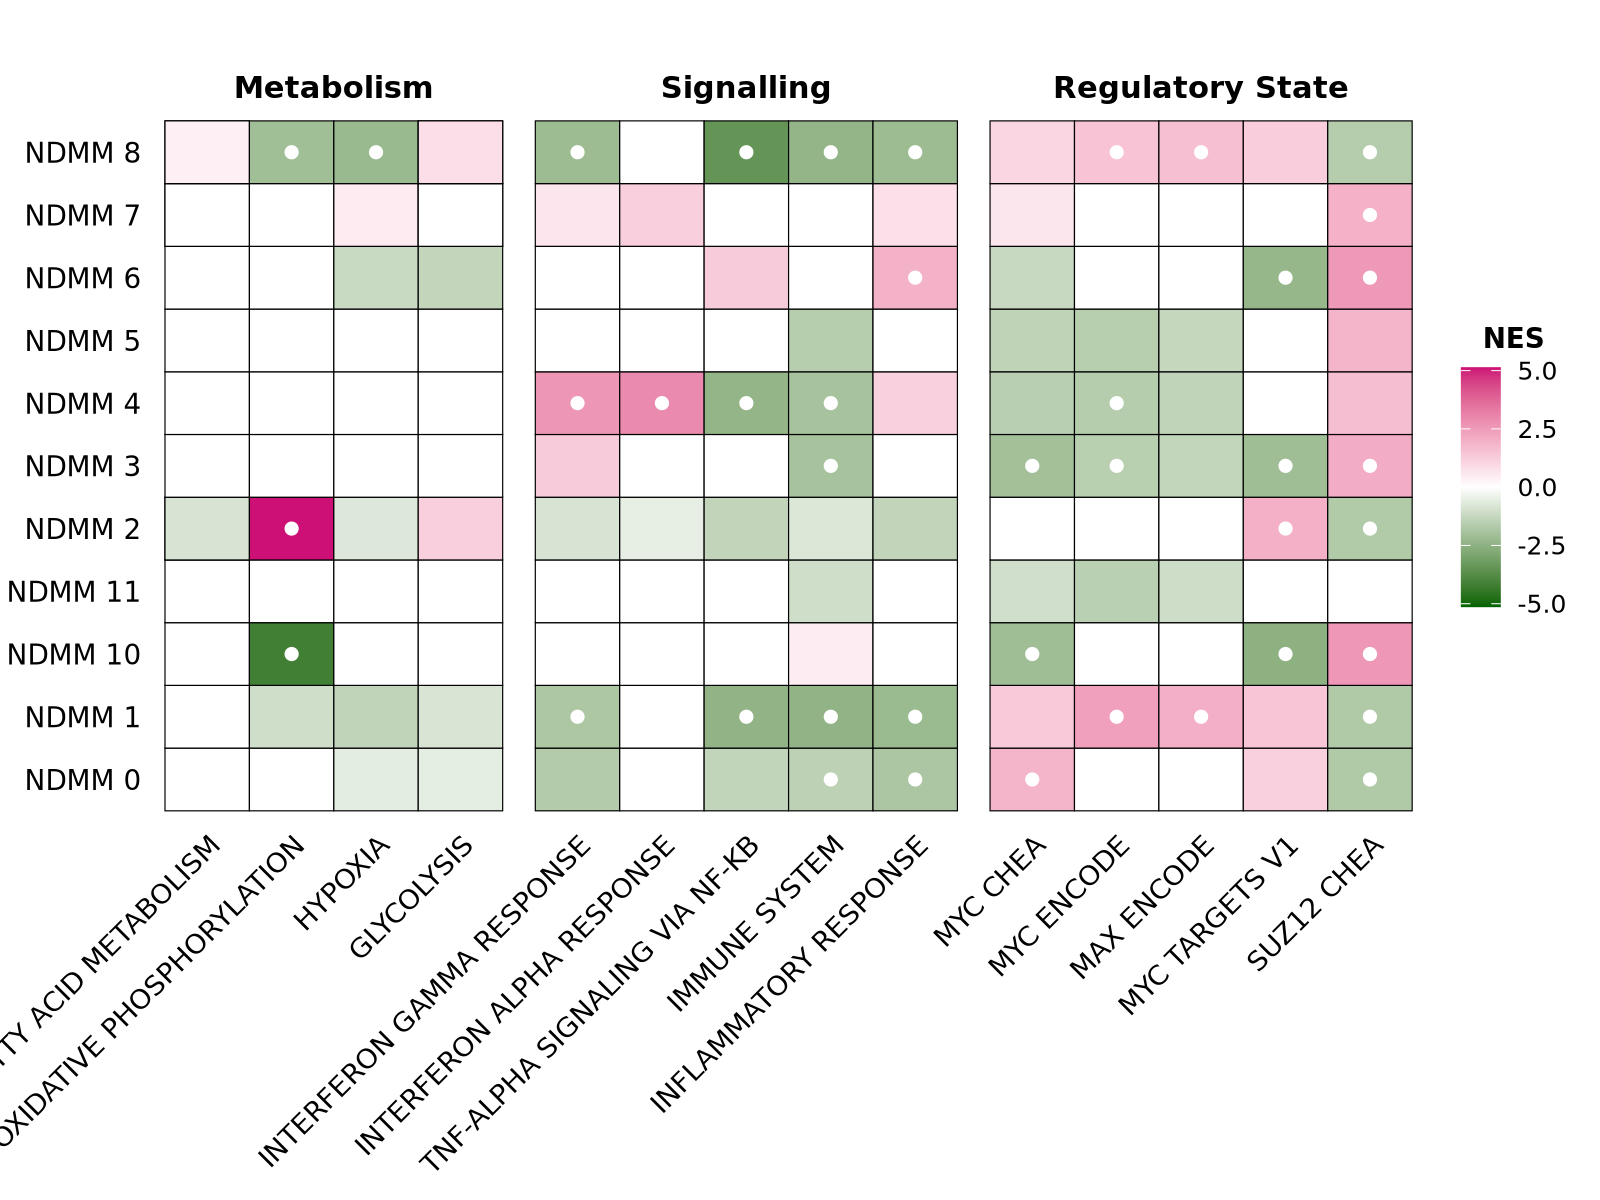

In [2]:
# Load required libraries
suppressPackageStartupMessages({
  library(dplyr)
  library(ggplot2)
  library(patchwork)
  library(stringr)
})


# Read the data
data <- read.csv("../../data/figure-inputs/figure_2/fgsea_bmmc_all_clusters_combined_ASIS_New.csv")

# Rename Cluster to celltype to work with existing functions
data <- data %>%
  mutate(celltype = paste0("NDMM ", Cluster)) %>%
  select(-Cluster) %>%
  filter(pathway != "Oxidative Phosphorylation")

# Define pathway categories with the ACTUAL pathway names from your data
pathway_categories <- list(
  "Metabolism" = c(
    "FATTY ACID METABOLISM",
    "Oxidative Phosphorylation",
    "HYPOXIA",
    "GLYCOLYSIS"
  ),
  "Signalling" = c(
    "INTERFERON GAMMA RESPONSE",
    "INTERFERON ALPHA RESPONSE",
    "TNF-alpha Signaling via NF-kB",
    "Immune System",
    "Inflammatory Response"
  ),
  "Regulatory State" = c(
    "MYC CHEA", 
    "MYC ENCODE", 
    "MAX ENCODE",
    "Myc Targets V1",
    "SUZ12 CHEA"
  )
)

# Get all pathways from categories
all_pathways <- unlist(pathway_categories)

# Create the heatmap
plot <- create_pathway_heatmap(
  data = data,
  celltypes = NULL, # Use all cell types (clusters)
  pathway_method = "manual",
  pathway_list = all_pathways,
  pathway_categories = pathway_categories,
  padj_threshold = 0.05,
  title = "",
  plot_width = 8,
  plot_height = 6,
  max_label_length = 50,
  base_font_size = 12,
  axis_text_x_size = 10,
  axis_text_y_size = 10,
  strip_text_size = 11,
  axis_text_x_angle = 45
)

# Display the plot
print(plot)

In [3]:
ggsave("../../data/figure-outputs/supplementary-1/sup_1h.pdf", plot = plot, width = 8, height = 6, device = cairo_pdf)